# 01 — Frame Extraction & Annotation Prep

End-to-end from raw video to a trainable POLO point-detection dataset:

1. **Index** the videos and **extract** representative frames (k-means)
2. **Stage** frames for CVAT upload
3. *(optional)* **Pre-annotate** with an existing POLO model
4. **[Annotate in CVAT]** — points labelled `thorax` with a `class` attribute
5. **Convert** the exported CVAT XML to POLO labels (`cvat_converted`)
6. **Build the feeder-only split** from the frozen `split_assignment.json`

- **Inputs:** raw videos under `media/`; later, the CVAT XML export in `labels/`
- **Outputs:** `frames/`, `cvat_converted/`, and `feeder_only/` (the training set)

Set `DATASET_BASE` (below) to your mosaic Dataset root. The default points at the
local Feb-2026 snapshot for smoke-testing; on the training machine point it at the
live dataset (e.g. `/home/beesbook/feeder_detection_model/dataset`).

In [21]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import json
import shutil
import xml.etree.ElementTree as ET
from xml.dom import minidom
import zipfile

import cv2
import yaml
import pandas as pd
import matplotlib.pyplot as plt

from mosaic.core.dataset import Dataset, new_dataset_manifest
from mosaic.tracking import extract_frames, get_frame_manifests, list_frame_runs
import mosaic.tracking.pose_training as pose
from ultralytics import YOLO

# Make the repo-root config.py importable regardless of the kernel's working dir
# (this notebook lives in notebooks/, config.py is one level up).
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / 'config.py').exists() and _REPO_ROOT != _REPO_ROOT.parent:
    _REPO_ROOT = _REPO_ROOT.parent
sys.path.insert(0, str(_REPO_ROOT))
import config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [22]:
# ── mosaic Dataset root ──
DATASET_BASE = Path('/Volumes/JD-SSD/feeder-detection-model/dataset')       
manifest_path = DATASET_BASE / 'dataset.yaml'

# ── Frame extraction ──
VIDEO_EXTENSIONS = ['.h264']   # feeder/exit cams record raw H.264
N_FRAMES = 20                  # frames per video (matches the published run kmeans-9cda3f575c)
EXTRACTION_METHOD = 'kmeans'   # 'kmeans' or 'uniform'
CANDIDATE_STEP = 5             # candidate-frame stride for k-means
RANDOM_STATE = 42
SEQUENCES = None               # None = every indexed video; or a list of video stems

# ── CVAT point-annotation schema ──
LABEL_NAME = 'thorax'          # CVAT label (point type)
CLASS_ATTR = 'class'           # CVAT attribute carrying the bee class
CLASS_NAMES = config.CLASS_NAMES
RADII = config.RADII           # class -> detection radius (px)
DEVICE = config.auto_device()
IMGSZ = config.IMGSZ
POLO_CONF = config.CONF

# ── CVAT -> POLO conversion split (the feeder-only session split is applied later) ──
SPLIT = (0.8, 0.15, 0.05)
SEED = 42

## Create / load the dataset

In [4]:
rewrite = False
if rewrite or not manifest_path.exists():
    new_dataset_manifest(
        name='feeder_detection_model',
        base_dir=DATASET_BASE,
        index_format='group/sequence',
        outfile=manifest_path,
    )

ds = Dataset(manifest_path).load()
CVAT_UPLOAD_DIR = DATASET_BASE / '_cvat_upload'
CONVERTED_DIR = config.cvat_converted_dir(ds)

print('Dataset:', ds.name)
for k, v in ds.roots.items():
    print(f'  {k}: {v}')
print('CVAT upload dir:', CVAT_UPLOAD_DIR)
print('Converted POLO dir:', CONVERTED_DIR)

Dataset: feeder_detection_model
  media: media
  features: features
  labels: labels
  models: models
  tracks: tracks
  tracks_raw: tracks_raw
  frames: frames
CVAT upload dir: /Volumes/JD-SSD/feeder-detection-model/dataset/_cvat_upload
Converted POLO dir: /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo-yolo11/_polo_data/cvat_converted


## Index media (ffprobe metadata -> media/index.csv)

In [5]:
ds.index_media(search_dirs=[ds.get_root('media')], extensions=VIDEO_EXTENSIONS)

media_idx = pd.read_csv(Path(ds.get_root('media')) / 'index.csv')
print(f'{len(media_idx)} videos indexed')
media_idx[['name', 'width', 'height', 'fps']].head()

[index_media] Wrote 127 entries -> /Volumes/JD-SSD/feeder-detection-model/dataset/media/index.csv
127 videos indexed


,name,width,height,fps
0,feedercamA_2025-07-01-18-55-09.h264,1920,646,25.0
1,exitcamA_2025-06-23-17-18-23.h264,1920,646,25.0
2,exitcamA_2025-07-05-06-22-07.h264,1920,646,25.0
3,exitcamA_2025-07-07-16-25-06.h264,1920,646,25.0
4,exitcamA_2025-07-10-21-06-37.h264,1920,646,25.0


## Extract frames

In [6]:
run_id = extract_frames(
    ds,
    n_frames=N_FRAMES,
    method=EXTRACTION_METHOD,
    sequences=SEQUENCES,
    candidate_step=CANDIDATE_STEP,
    random_state=RANDOM_STATE,
)
print('Run ID:', run_id)

[extract_frames] skip feedercamA_2025-07-04-08-37-21 (exists, overwrite=False)
[extract_frames] skip feedercamA_2025-07-04-10-28-39 (exists, overwrite=False)
[extract_frames] skip feedercamA_2025-07-04-19-00-13 (exists, overwrite=False)
[extract_frames] skip feedercamA_2025-07-09-08-33-12 (exists, overwrite=False)
[extract_frames] skip feedercamA_2025-07-09-11-55-25 (exists, overwrite=False)
[extract_frames] skip feedercamA_2025-07-09-15-40-03 (exists, overwrite=False)
[extract_frames] skip feedercamB_2025-06-22-06-53-04 (exists, overwrite=False)
[extract_frames] skip feedercamB_2025-06-22-10-20-11 (exists, overwrite=False)
[extract_frames] skip feedercamB_2025-06-22-14-47-01 (exists, overwrite=False)
[extract_frames] skip feedercamB_2025-06-30-07-57-44 (exists, overwrite=False)
[extract_frames] skip feedercamB_2025-06-30-18-53-28 (exists, overwrite=False)
[extract_frames] skip feedercamB_2025-06-30-20-32-17 (exists, overwrite=False)
[extract_frames] skip feedercamB_2025-07-04-11-35-47

## Visual check

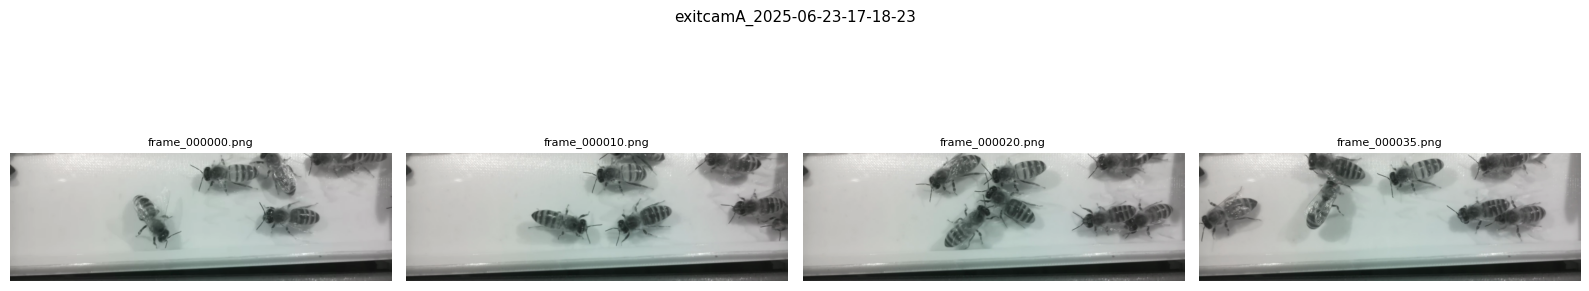

In [7]:
manifests = get_frame_manifests(ds, EXTRACTION_METHOD)
sample = manifests[0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, rec in zip(axes, sample['files'][:4]):
    img = cv2.imread(str(rec['path']))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(rec['path']).name, fontsize=8)
    ax.axis('off')
fig.suptitle(Path(sample['video_path']).stem, fontsize=11)
plt.tight_layout()
plt.show()

---
# Annotation Prep & Feeder-Only Split

Everything below turns the extracted frames + CVAT annotations into the trainable
POLO dataset. Re-uses `ds`, `CVAT_UPLOAD_DIR`, `CONVERTED_DIR`, and the config
above — no separate setup needed.

## 1 — Stage frames for CVAT upload

Copy extracted frames into one flat directory, prefixing each with its video
stem to avoid filename collisions. (For incremental annotation rounds, stage new
sessions into a separate `_cvat_upload_<batch>/` and also add them here.)

In [23]:
# Stage frames into one flat dir for CVAT. This dataset was built from MORE THAN ONE
# k-means run (e.g. a 20-frame and a 10-frame run) — stage ALL runs so every frame the
# annotations reference is present. get_frame_manifests(..., run_id=None) would grab only
# the latest run, which is what previously left frames un-staged.
FRAME_RUN_IDS = None   # None = every run of EXTRACTION_METHOD; or a list like ['kmeans-9cda3f575c', 'kmeans-c4a1a16a31']

runs = list_frame_runs(ds, EXTRACTION_METHOD)
run_ids = sorted(runs['run_id'].unique()) if FRAME_RUN_IDS is None else list(FRAME_RUN_IDS)
print('Staging from runs:', run_ids)

CVAT_UPLOAD_DIR.mkdir(parents=True, exist_ok=True)
file_count = 0
for rid in run_ids:
    for manifest in get_frame_manifests(ds, EXTRACTION_METHOD, run_id=rid):
        video_stem = Path(manifest['video_path']).stem
        prefix = video_stem.replace('-', '_').replace(' ', '_')[:40] + '__'
        for rec in manifest['files']:
            src = Path(rec['path'])
            dest = CVAT_UPLOAD_DIR / (prefix + src.name)
            if not dest.exists():
                shutil.copy2(src, dest)
                file_count += 1

print(f'Staged {file_count} new frames -> {CVAT_UPLOAD_DIR} '
      f'({len(list(CVAT_UPLOAD_DIR.glob("*.png")))} total)')

Staging from runs: ['kmeans-9cda3f575c', 'kmeans-c4a1a16a31']
Staged 356 new frames -> /Volumes/JD-SSD/feeder-detection-model/dataset/_cvat_upload (2896 total)


## 2 — (Optional) POLO pre-annotations

If a POLO model already exists, run it on the staged frames to seed CVAT with
pre-annotations (much faster than annotating from scratch). Skip on the first
annotation round, when no model exists yet.

In [ ]:
GENERATE_PREANNOTATIONS = False  # set True once a POLO model is available

if GENERATE_PREANNOTATIONS:
    polo_best = pose.find_best_model(str(ds.get_root('models') / config.POLO_MODEL_NAME))
    assert polo_best, 'No POLO model found for pre-annotation'
    polo_model = YOLO(str(polo_best))
    staged = sorted(CVAT_UPLOAD_DIR.glob('*.png'))

    root = ET.Element('annotations')
    ET.SubElement(root, 'version').text = '1.1'
    n_ann = 0
    for img_id, fp in enumerate(staged):
        img = cv2.imread(str(fp))
        h, w = img.shape[:2]
        image_el = ET.SubElement(root, 'image', {
            'id': str(img_id), 'name': fp.name, 'width': str(w), 'height': str(h)})
        for x, y, cls, conf in config.polo_predict(polo_model, fp):
            name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else CLASS_NAMES[0]
            pt = ET.SubElement(image_el, 'points', {
                'label': LABEL_NAME, 'occluded': '0', 'source': 'auto',
                'points': f'{x:.2f},{y:.2f}', 'z_order': '0'})
            ET.SubElement(pt, 'attribute', {'name': CLASS_ATTR}).text = name
            n_ann += 1

    xml_str = minidom.parseString(ET.tostring(root, encoding='unicode')).toprettyxml(indent='  ')
    out_xml = CVAT_UPLOAD_DIR / 'preannotations_cvat.xml'
    out_xml.write_text(xml_str)
    with zipfile.ZipFile(CVAT_UPLOAD_DIR / 'preannotations_cvat.zip', 'w') as zf:
        zf.write(out_xml, 'annotations.xml')
    print(f'Wrote {n_ann} pre-annotations -> {out_xml}')
else:
    print('Skipping pre-annotation generation (GENERATE_PREANNOTATIONS=False)')

## 3 — Annotate in CVAT

1. Create a CVAT project with a **Points** label `thorax`
2. Add a `class` attribute (select) with values `UnmarkedBee`, `MarkedBee`,
   `BeeInCell`, `UpsideDownBee`
3. Upload the staged images; optionally import `preannotations_cvat.zip` (format
   **CVAT 1.1**) as a starting point
4. Review/correct, then export as **CVAT for images 1.1**
5. Place the exported XML in the dataset `labels/` directory

## 4 — Import CVAT XML & convert to POLO labels

Auto-discovers and merges all annotation XMLs in `labels/` (for multi-batch
workflows), then converts points to POLO labels (`class_id radius x_rel y_rel`).

In [24]:
labels_dir = DATASET_BASE / 'labels'
annotation_xmls = sorted(p for p in labels_dir.glob('*.xml') if not p.name.startswith('_'))
print(f'Found {len(annotation_xmls)} annotation XML(s)')
for p in annotation_xmls:
    tree = ET.parse(p)
    n_img = len(tree.findall('.//image'))
    n_ann = sum(len(im.findall('points')) for im in tree.findall('.//image'))
    print(f'  {p.name}: {n_img} images, {n_ann} annotations')

if len(annotation_xmls) == 0:
    raise FileNotFoundError(f'No annotation XMLs in {labels_dir}/. Export from CVAT first.')
elif len(annotation_xmls) == 1:
    CVAT_XML_PATH = annotation_xmls[0]
else:
    merged = {}
    for xml_path in annotation_xmls:
        for im in ET.parse(xml_path).findall('.//image'):
            merged[im.get('name')] = im
    root = ET.Element('annotations')
    ET.SubElement(root, 'version').text = '1.1'
    for im in sorted(merged.values(), key=lambda e: e.get('name', '')):
        root.append(im)
    CVAT_XML_PATH = labels_dir / '_merged_annotations.xml'
    ET.ElementTree(root).write(str(CVAT_XML_PATH), encoding='unicode', xml_declaration=True)
print('Using:', CVAT_XML_PATH.name)

Found 2 annotation XML(s)
  batch2_annotations_2026_03_12_10_49_04_cvat for images 1.1.xml: 860 images, 4382 annotations
  job_1_annotations_2026_02_20_07_13_46_cvat for images 1.1.xml: 820 images, 4074 annotations
Using: _merged_annotations.xml


In [25]:
schema = pose.cvat_points.convert_cvat_points_polo(
    cvat_xml_path=CVAT_XML_PATH,
    images_dir=CVAT_UPLOAD_DIR,
    output_dir=CONVERTED_DIR,
    radii=RADII,
    class_attribute=CLASS_ATTR,
    class_names=CLASS_NAMES,
    split=SPLIT,
    symlink_images=True,
    seed=SEED,
    split_by='group',
)
print('Classes:', schema.names)
print('Radii:', schema.radii)

[cvat_points_polo] Wrote 1246 labels to /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/cvat_converted
  Classes: ['UnmarkedBee', 'MarkedBee', 'BeeInCell', 'UpsideDownBee']
  Counts: {'UnmarkedBee': 7892, 'MarkedBee': 398, 'UpsideDownBee': 173}
  Radii: {0: 100.0, 1: 100.0, 2: 100.0, 3: 100.0}
  Splits (by group): train=990 (85 groups), valid=196 (16 groups), test=60 (6 groups)
Classes: ['UnmarkedBee', 'MarkedBee', 'BeeInCell', 'UpsideDownBee']
Radii: {0: 100.0, 1: 100.0, 2: 100.0, 3: 100.0}


In [26]:
data_yaml = pose.make_polo_data_yaml(
    dataset_root=str(CONVERTED_DIR),
    class_names=CLASS_NAMES,
    radii=schema.radii,
)
print(Path(data_yaml).read_text())
pose.check_dataset(str(CONVERTED_DIR))

path: /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/cvat_converted
train: train/images
val: valid/images
names:
  0: UnmarkedBee
  1: MarkedBee
  2: BeeInCell
  3: UpsideDownBee
radii:
  0: 100.0
  1: 100.0
  2: 100.0
  3: 100.0
test: test/images

Dataset: /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/cvat_converted

[train] labels: /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/cvat_converted/train/labels
  Class counts: {0: 6744, 1: 296, 3: 142}
  Empty: 0 / 990

[valid] labels: /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/cvat_converted/valid/labels
  Class counts: {0: 815, 1: 69, 3: 15}
  Empty: 0 / 196

[test] labels: /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/cvat_converted/test/labels
  Class counts: {0: 333, 1: 33, 3: 16}
  Empty: 0 / 60


## 5 — Build the feeder-only split

The deployed model is **evaluated only on feeder cameras**, so the training
split is rebuilt by recording session:

- all **exit-cam** images -> `train` (extra learning signal, never evaluated)
- **feeder** sessions split ~75 / 12.5 / 12.5 into train / valid / test

The split is **frozen** in `split_assignment.json` (1246 entries, seed 42,
session-grouped — no temporal leakage). This cell re-buckets the converted
images/labels into `feeder_only/` via symlinks and writes its `data.yaml`.

On the smoke-test snapshot (no exit cams, fewer sessions) many entries will be
reported missing — that is expected; the final remote dataset matches exactly.

In [27]:
SPLIT_ASSIGNMENT = _REPO_ROOT / 'split_assignment.json'
FEEDER_ONLY = config.feeder_only_dir(ds)

assignments = json.load(open(SPLIT_ASSIGNMENT))
print(f'{len(assignments)} entries in split_assignment.json')

# Index converted images by filename across its train/valid/test subdirs
src_index = {}
for sub in ('train', 'valid', 'test'):
    img_dir = CONVERTED_DIR / sub / 'images'
    if img_dir.exists():
        for p in img_dir.glob('*.png'):
            src_index[p.name] = p
print(f'{len(src_index)} converted images available')

for sub in ('train', 'valid', 'test'):
    (FEEDER_ONLY / sub / 'images').mkdir(parents=True, exist_ok=True)
    (FEEDER_ONLY / sub / 'labels').mkdir(parents=True, exist_ok=True)

created = {'train': 0, 'valid': 0, 'test': 0}
missing, no_label = [], []
for fname, info in sorted(assignments.items()):
    if fname not in src_index:
        missing.append(fname)
        continue
    src_img = src_index[fname]                                  # cvat_converted/<sub>/images/<name> (symlink)
    src_lbl = src_img.parent.parent / 'labels' / (src_img.stem + '.txt')  # cvat_converted/<sub>/labels/<stem>.txt
    dst_img = FEEDER_ONLY / info['split'] / 'images' / fname
    dst_lbl = FEEDER_ONLY / info['split'] / 'labels' / (src_img.stem + '.txt')
    if not dst_img.exists():
        dst_img.symlink_to(src_img.resolve())                  # point feeder_only image at the real frame file
    if src_lbl.exists():
        if not dst_lbl.exists():
            dst_lbl.symlink_to(src_lbl.resolve())              # point feeder_only label at the real .txt
    else:
        no_label.append(fname)
    created[info['split']] += 1

yaml.safe_dump(
    {'names': {i: n for i, n in enumerate(CLASS_NAMES)},
     'path': str(FEEDER_ONLY.resolve()),
     'radii': {i: 100.0 for i in range(len(CLASS_NAMES))},
     'train': 'train/images', 'val': 'valid/images', 'test': 'test/images'},
    open(FEEDER_ONLY / 'data.yaml', 'w'), sort_keys=True)

print('feeder_only built:', created, '->', FEEDER_ONLY)
if missing:
    print(f'NOTE: {len(missing)} split entries not in this dataset '
          '(not yet annotated/converted here — see the debug cell).')
if no_label:
    print(f'WARNING: {len(no_label)} images had no matching label file (check the conversion step).')

1246 entries in split_assignment.json
1246 converted images available
feeder_only built: {'train': 977, 'valid': 133, 'test': 136} -> /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/feeder_only


In [28]:
# Verify feeder-only camera/split breakdown
import collections
counts = collections.Counter()
for sub in ('train', 'valid', 'test'):
    for p in (FEEDER_ONLY / sub / 'images').glob('*.png'):
        counts[(config.camera_of(p.name), sub)] += 1
for k in sorted(counts):
    print(f'  {k[0]:6s} {k[1]:5s}: {counts[k]}')

  exit   train: 189
  feeder test : 136
  feeder train: 788
  feeder valid: 133


In [ ]:
# ── Debug: are any split_assignment.json entries are missing from this dataset? ──
import json, collections
from pathlib import Path

assignments = json.load(open(SPLIT_ASSIGNMENT))

# What's actually converted (pool across all cvat_converted splits, by filename)
src_index = {}
for sub in ('train', 'valid', 'test'):
    d = CONVERTED_DIR / sub / 'images'
    if d.exists():
        for p in d.glob('*.png'):
            src_index[p.name] = p

missing = [f for f in assignments if f not in src_index]
present = [f for f in assignments if f in src_index]
print(f'{len(present)}/{len(assignments)} present | {len(missing)} missing\n')

def session_of(name):
    return name.rsplit('__frame_', 1)[0]

# 1) Missing broken down by camera x split (what 'complete' should look like vs now)
miss_cat = collections.Counter((assignments[f]['cam_type'], assignments[f]['split']) for f in missing)
all_cat  = collections.Counter((v['cam_type'], v['split']) for v in assignments.values())
print('Missing  vs  expected total, by (camera, split):')
for k in sorted(all_cat):
    print(f'  {k[0]:6s} {k[1]:5s}: missing {miss_cat.get(k, 0):4d} / {all_cat[k]:4d}')

# 2) WHY missing: not staged at all (no frame/video) vs staged but not converted (no annotation)
staged = {p.name for p in CVAT_UPLOAD_DIR.glob('*.png')} if CVAT_UPLOAD_DIR.exists() else set()
miss_unstaged = [f for f in missing if f not in staged]   # source frame/video absent
miss_staged   = [f for f in missing if f in staged]       # frame present, but no CVAT label
print(f'\nCause:  {len(miss_unstaged)} not staged at all (source frame/video missing)  |  '
      f'{len(miss_staged)} staged but not converted (annotation/label missing)')

# 3) WHICH recordings to add — sessions that are fully vs partially absent
miss_sess    = collections.Counter(session_of(f) for f in missing)
present_sess = {session_of(f) for f in present}
fully   = sorted(s for s in miss_sess if s not in present_sess)
partial = sorted(s for s in miss_sess if s in present_sess)
print(f'\n{len(fully)} fully-absent sessions, {len(partial)} partially-present sessions')
print('\nFully-absent sessions  (camera | session | #frames expected):')
for s in fully:
    print(f'  {"exit  " if "exitcam" in s else "feeder"} | {s} | {miss_sess[s]}')
if partial:
    print('\nPartially-present sessions  (missing / expected):')
    for s in partial:
        print(f'  {s}: {miss_sess[s]} / {miss_sess[s] + sum(1 for f in present if session_of(f)==s)}')


1246/1246 present | 0 missing

Missing  vs  expected total, by (camera, split):
  exit   train: missing    0 /  189
  feeder test : missing    0 /  136
  feeder train: missing    0 /  788
  feeder valid: missing    0 /  133

Cause:  0 not staged at all (source frame/video missing)  |  0 staged but not converted (annotation/label missing)

0 fully-absent sessions, 0 partially-present sessions

Fully-absent sessions  (camera | session | #frames expected):
